In [52]:
## -- Importar librearias necesarios
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
# --- Cargar dataset ---
df = pd.read_excel("../data/raw/database_non-shows.xlsx")
# df = pd.read_excel("../database_non-shows.xlsx")
# df = pd.read_excel("database_non-shows.xlsx")

# Vista general del dataset

### Número de filas y columnas

In [54]:
print(f'Número de filas : {df.shape[0]}')
print(f'Número de columnas : {df.shape[1]} \n')

Número de filas : 18587
Número de columnas : 13 



### Tipo de datos y estadísticas descriptivas

In [55]:
# --- Vista general ---
print("Tipo de datos y estadísticas descriptivas : \n")
df.info()
df.describe()

Tipo de datos y estadísticas descriptivas : 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18587 entries, 0 to 18586
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Appointment Type                   18587 non-null  int64
 1   Age                                18587 non-null  int64
 2   Sex                                18587 non-null  int64
 3   Insurance Type                     18587 non-null  int64
 4   Number of Diseases                 18587 non-null  int64
 5   Recent Hospitalization             18587 non-null  int64
 6   Number of Medications              18587 non-null  int64
 7   Hour                               18587 non-null  int64
 8   Day                                18587 non-null  int64
 9   Month                              18587 non-null  int64
 10  Creation to Assignment Interval    18587 non-null  int64
 11  Number of Previous Attendance     

,Appointment Type,Age,Sex,Insurance Type,Number of Diseases,Recent Hospitalization,Number of Medications,Hour,Day,Month,Creation to Assignment Interval,Number of Previous Attendance,Number of Previous Non-Attendance
count,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000
mean,0.346156,50.152903,0.380804,2.792167,1.435519,0.037553,0.543229,11.582235,2.790176,6.216926,25.599774,2.680207,2.043794
std,0.475756,17.123270,0.489240,0.891696,1.111154,0.207959,1.232169,2.761017,2.046901,2.773017,28.656826,2.256370,3.431348
min,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,-1.000000,0.000000,0.000000
25%,0.000000,37.000000,0.000000,3.000000,1.000000,0.000000,0.000000,9.000000,1.000000,4.000000,8.000000,1.000000,0.000000
50%,0.000000,50.000000,0.000000,3.000000,1.000000,0.000000,0.000000,11.000000,3.000000,7.000000,19.000000,2.000000,1.000000
75%,1.000000,62.000000,1.000000,3.000000,2.000000,0.000000,0.000000,14.000000,4.000000,8.000000,35.000000,4.000000,3.000000
max,1.000000,104.000000,2.000000,8.000000,8.000000,6.000000,18.000000,21.000000,7.000000,12.000000,1673.000000,43.000000,77.000000


# Limpieza de datos

### Valores nulos y duplicados

In [56]:
print(f'Valores nulos por columna: \n\n{df.isnull().sum()} \n')
print(f'Número de filas duplicadas:\n{df.duplicated().sum()}')

Valores nulos por columna: 

Appointment Type                     0
Age                                  0
Sex                                  0
Insurance Type                       0
Number of Diseases                   0
Recent Hospitalization               0
Number of Medications                0
Hour                                 0
Day                                  0
Month                                0
Creation to Assignment Interval      0
Number of Previous Attendance        0
Number of Previous Non-Attendance    0
dtype: int64 

Número de filas duplicadas:
6


### Valores con espacios

In [57]:
for col in df.columns:
    # Convertir temporalmente a string para buscar espacios
    col_as_str = df[col].astype(str)

    # Detectar valores con espacios al inicio o al final
    espacios = col_as_str[col_as_str.str.contains(r'^\s+|\s+$', regex=True)]
    if not espacios.empty:
        print(f"{len(espacios)} registros con espacios extra en '{col}'")
        print(espacios.head())

    # Detectar valores no numéricos en columnas que deberían ser numéricas
    if df[col].dtype != 'object':
        try:
            pd.to_numeric(df[col], errors='raise')
        except Exception:
            print(f"La columna '{col}' tiene valores no numéricos inesperados.")

### Valores inválidos

In [58]:
condiciones = {
    'Appointment Type': ~df['Appointment Type'].isin([0, 1]),
    'Age': (df['Age'] < 18) | (df['Age'] > 120),
    'Sex': ~df['Sex'].isin([0, 1, 2]),
    'Insurance Type': ~df['Insurance Type'].isin(range(0, 9)),
    'Number of Diseases': (df['Number of Diseases'] < 0),
    'Recent Hospitalization': (df['Recent Hospitalization'] < 0),
    'Number of Medications': (df['Number of Medications'] < 0),
    'Hour': (df['Hour'] < 0) | (df['Hour'] > 23),
    'Day': ~df['Day'].between(0, 6),
    'Month': ~df['Month'].between(1, 12),
    'Creation to Assignment Interval': (df['Creation to Assignment Interval'] < 0),
    'Number of Previous Attendance': (df['Number of Previous Attendance'] < 0),
    'Number of Previous Non-Attendance': (df['Number of Previous Non-Attendance'] < 0),
}
# Reglas basadas en el diccionario del dataset
count_invalid = 0

# Crear una máscara booleana general que marca los registros inválidos
mask_invalid = pd.Series(False, index=df.index)

# Identificar registros inválidos según las reglas
for col, cond in condiciones.items():
    invalidos = df[cond]
    count_invalid += len(invalidos)
    mask_invalid = mask_invalid | cond  # combinar condiciones
    if len(invalidos) > 0:
        print(f"\n{len(invalidos)} valores inválidos en '{col}':")

print("\n-----------------------")
print(f"Total de datos con valores inválidos: {count_invalid}")

# Eliminar los registros inválidos del DataFrame
df_sin_errores_digitacion = df[~mask_invalid].copy()

print(f"\nTotal de registros antes: {len(df)}")
print(f"Total de registros después de eliminar inválidos: {len(df_sin_errores_digitacion)}")
print(f"Registros eliminados: {len(df) - len(df_sin_errores_digitacion)}")

# El numero de registros eliminados es mayor al numero de datos erroneos, porque puden haber filas con más de 1 error.


51 valores inválidos en 'Age':

129 valores inválidos en 'Day':

36 valores inválidos en 'Month':

1 valores inválidos en 'Creation to Assignment Interval':

-----------------------
Total de datos con valores inválidos: 217

Total de registros antes: 18587
Total de registros después de eliminar inválidos: 18391
Registros eliminados: 196


### Valores atípicos (Variables numéricas)

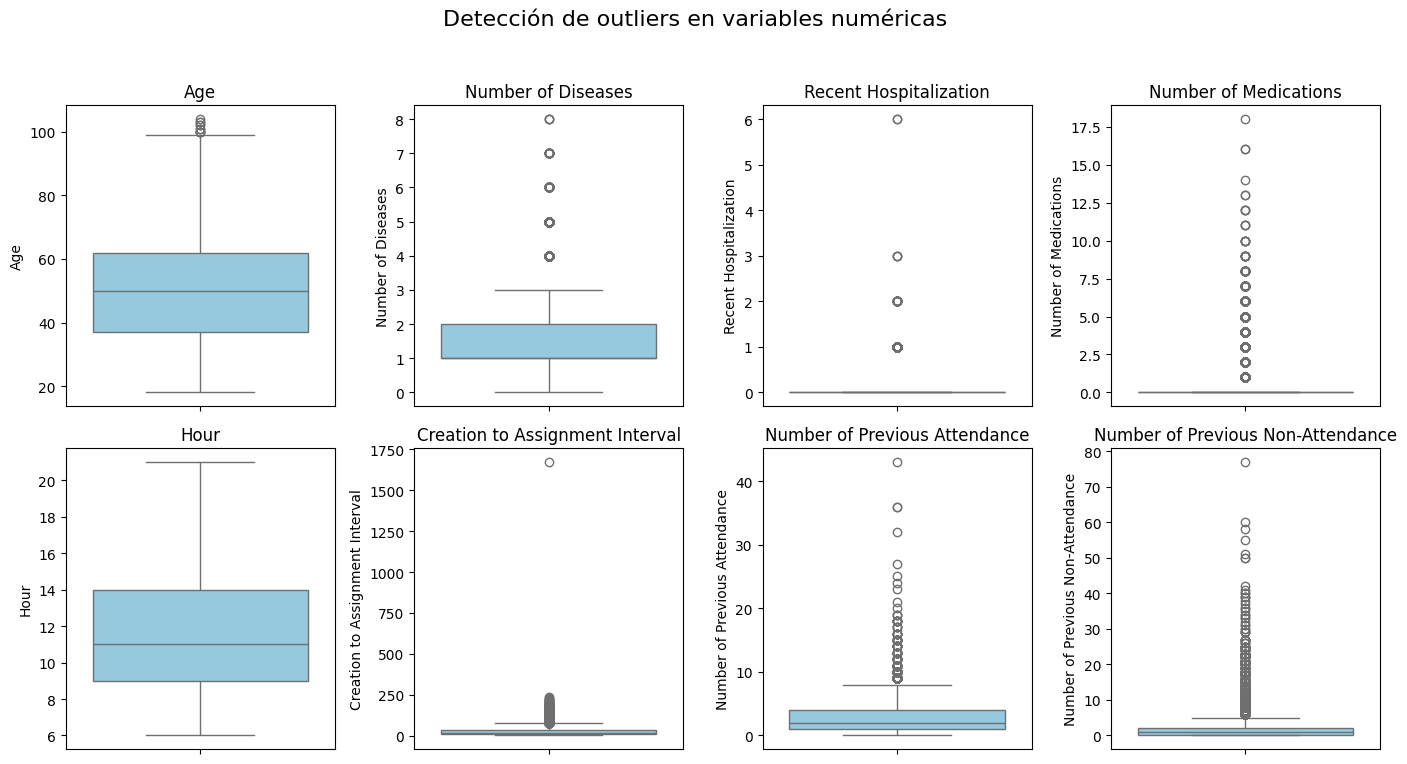

In [59]:
# Variables numéricas según tu descripción
df
num_cols = [
    'Age', 'Number of Diseases', 'Recent Hospitalization',
    'Number of Medications', 'Hour',
    'Creation to Assignment Interval',
    'Number of Previous Attendance', 'Number of Previous Non-Attendance'
]

# Boxplots para ver outliers
plt.figure(figsize=(14,8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df_sin_errores_digitacion[col], color='skyblue')
    plt.title(col)
plt.suptitle("Detección de outliers en variables numéricas", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [60]:
condicion_outlier = {
    'Creation to Assignment Interval': (df_sin_errores_digitacion['Creation to Assignment Interval'] > 365),
}

count_invalid = 0

# Crear una máscara booleana general que marca los registros inválidos
mask_invalid = pd.Series(False, index=df_sin_errores_digitacion.index)

# Identificar registros inválidos según las reglas
for col, cond in condicion_outlier.items():
    invalidos = df_sin_errores_digitacion[cond]
    count_invalid += len(invalidos)
    mask_invalid = mask_invalid | cond  # combinar condiciones
    if len(invalidos) > 0:
        print(f"\n{len(invalidos)} valores inválidos en '{col}':")

print("\n-----------------------")
# Eliminar los registros inválidos del DataFrame
df_limpio = df_sin_errores_digitacion[~mask_invalid].copy()

print(f"\nTotal de registros antes: {len(df_sin_errores_digitacion)}")
print(f"Total de registros después de eliminar outliers: {len(df_limpio)}")
eliminados_outliers = len(df_sin_errores_digitacion) - len(df_limpio)
print(f"Registros eliminados: {eliminados_outliers}")


1 valores inválidos en 'Creation to Assignment Interval':

-----------------------

Total de registros antes: 18391
Total de registros después de eliminar outliers: 18390
Registros eliminados: 1


## Resumen Limpieza

In [61]:
print(f'Total registros antes: {len(df)}')
print(f'Total registros después de limpieza: {len(df_limpio)}')
print(f'Total registros eliminados: {len(df)-len(df_limpio)}')
print(f'Porcentaje de registros eliminados: %{(len(df)-len(df_limpio))/len(df)*100}')

Total registros antes: 18587
Total registros después de limpieza: 18390
Total registros eliminados: 197
Porcentaje de registros eliminados: %1.0598805616828966


# EDA

### Distribución variables numéricas

<Figure size 1400x1000 with 0 Axes>

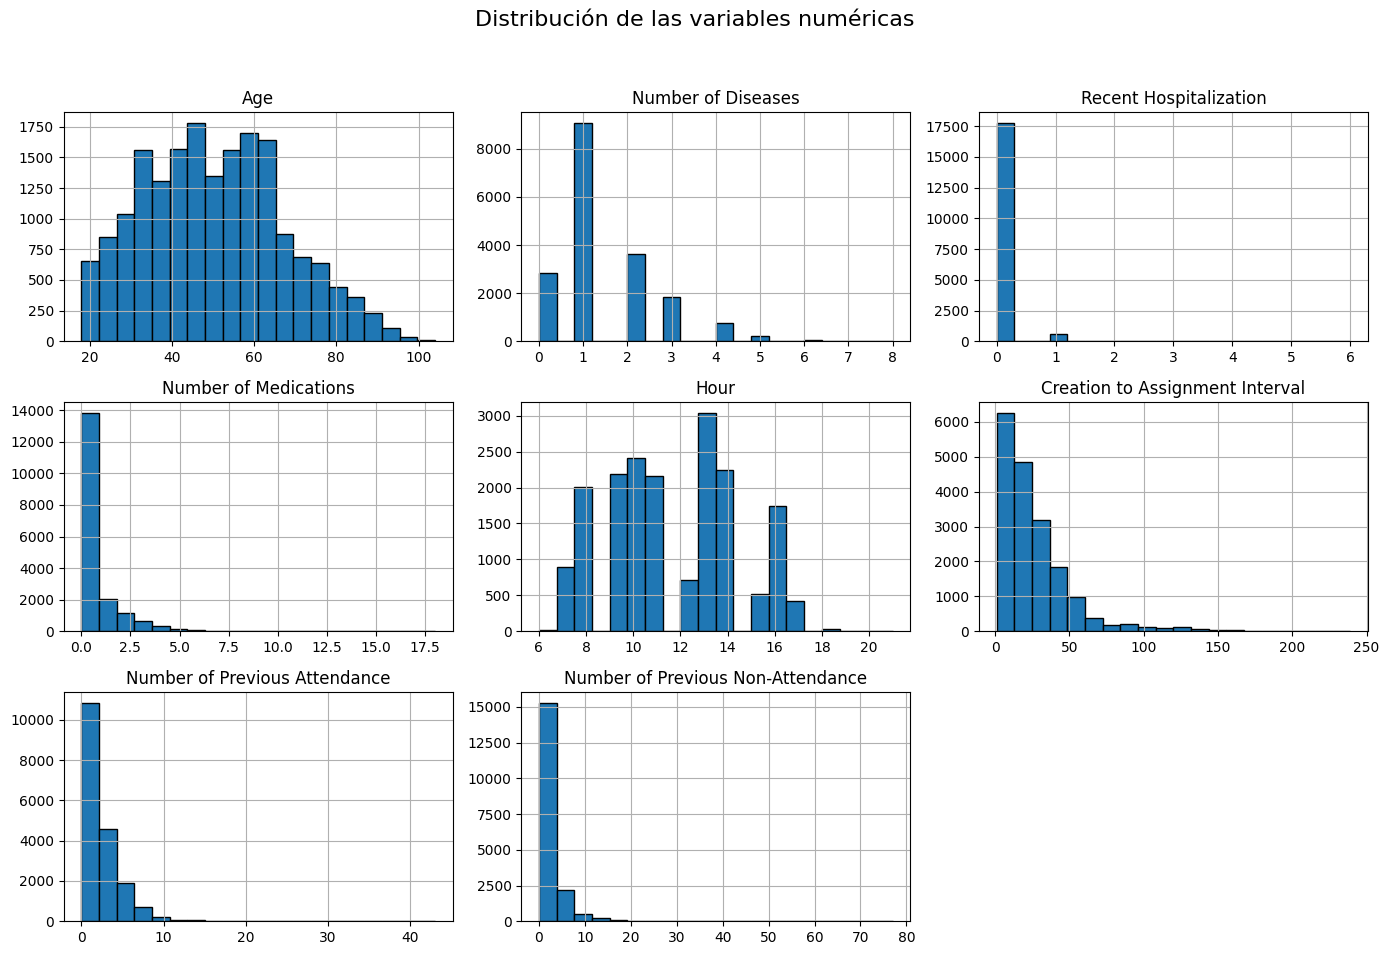

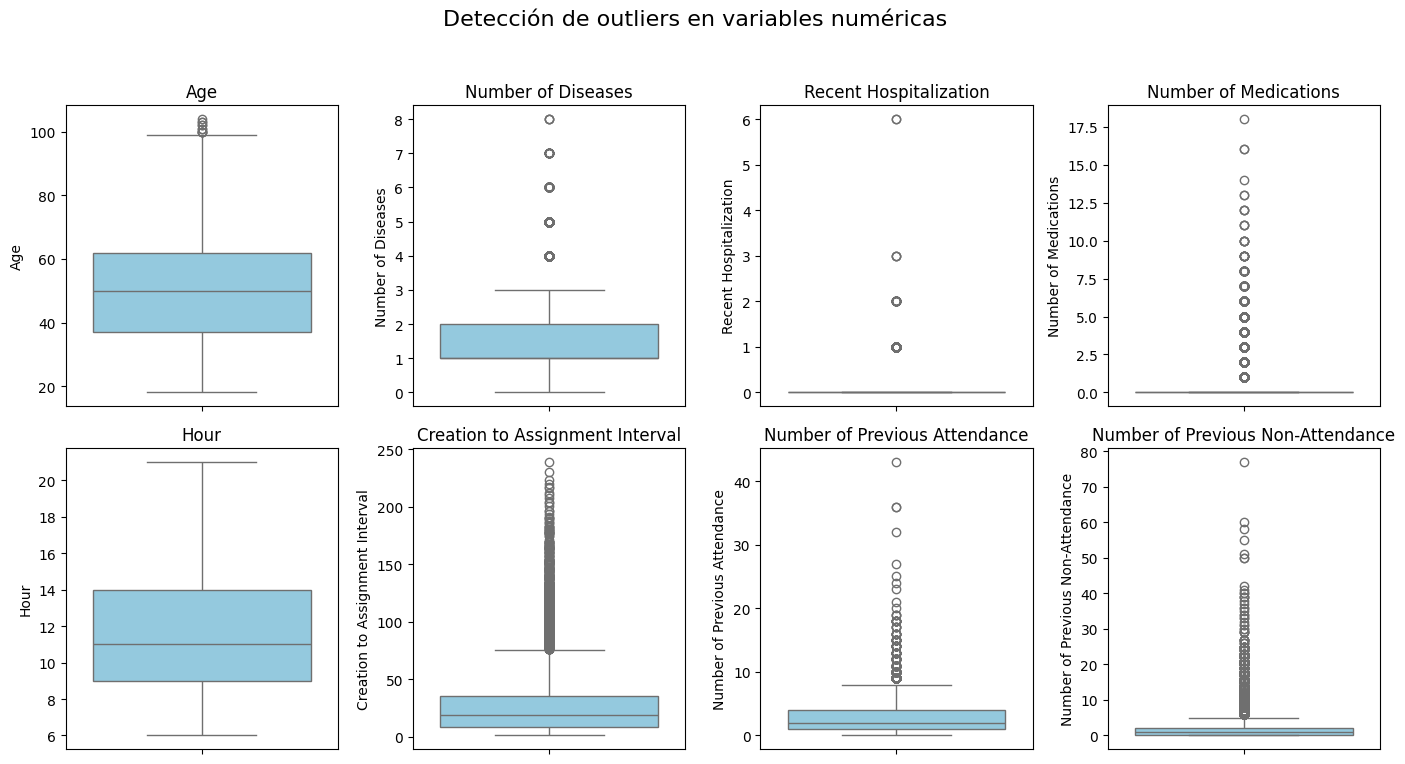

In [62]:
# Variables numéricas
num_cols = [
    'Age', 'Number of Diseases', 'Recent Hospitalization',
    'Number of Medications', 'Hour',
    'Creation to Assignment Interval',
    'Number of Previous Attendance', 'Number of Previous Non-Attendance'
]

# Histogramas
plt.figure(figsize=(14,10))
df_limpio[num_cols].hist(figsize=(14,10), bins=20, edgecolor='black')
plt.suptitle("Distribución de las variables numéricas", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Boxplots para ver outliers
plt.figure(figsize=(14,8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df_limpio[col], color='skyblue')
    plt.title(col)
plt.suptitle("Detección de outliers en variables numéricas", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Distribución variables categóricas


 Frecuencia de variables categóricas:

--- Sex ---
Sex
0    11427
1     6930
2       33
Name: count, dtype: int64


C:\Users\alejo\AppData\Local\Temp\ipykernel_23136\581492274.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_limpio, palette='Set2', order=sorted(df_limpio[col].unique()))


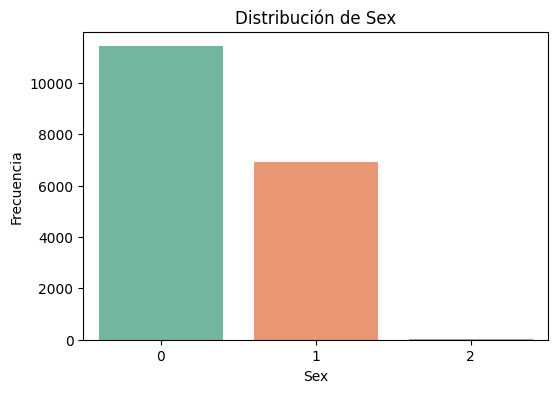


--- Insurance Type ---
Insurance Type
0      601
1     1670
2       42
3    15241
4      658
5       12
6        7
7      153
8        6
Name: count, dtype: int64


C:\Users\alejo\AppData\Local\Temp\ipykernel_23136\581492274.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_limpio, palette='Set2', order=sorted(df_limpio[col].unique()))


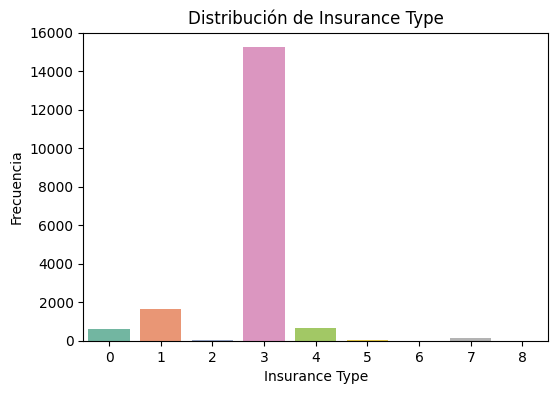


--- Day ---
Day
0    3287
1    2863
2    2638
3    2808
4    2320
5    2008
6    2466
Name: count, dtype: int64


C:\Users\alejo\AppData\Local\Temp\ipykernel_23136\581492274.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_limpio, palette='Set2', order=sorted(df_limpio[col].unique()))


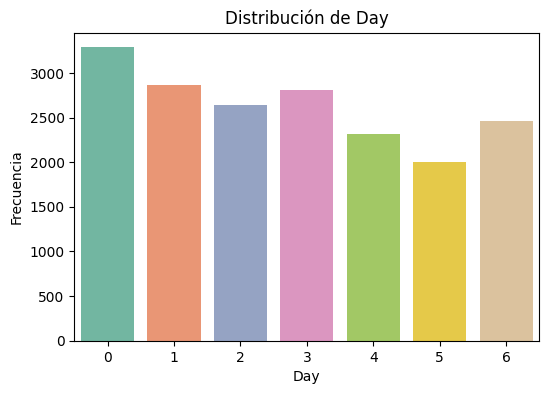

C:\Users\alejo\AppData\Local\Temp\ipykernel_23136\581492274.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_limpio, palette='Set2', order=sorted(df_limpio[col].unique()))



--- Month ---
Month
1     1191
2     1103
3     1392
4     1406
5     1743
6     1940
7     2209
8     3065
9     3166
10     378
11     406
12     391
Name: count, dtype: int64


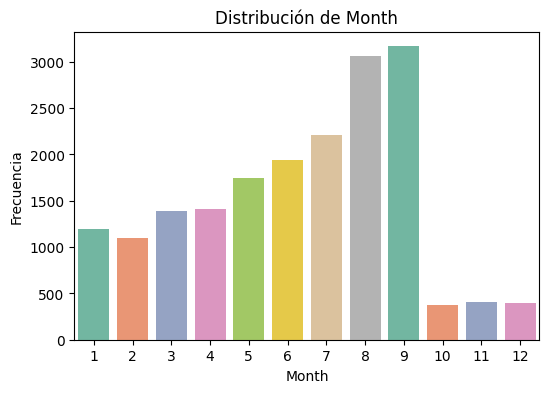

C:\Users\alejo\AppData\Local\Temp\ipykernel_23136\581492274.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_limpio, palette='Set2', order=sorted(df_limpio[col].unique()))



--- Appointment Type ---
Appointment Type
0    12114
1     6276
Name: count, dtype: int64


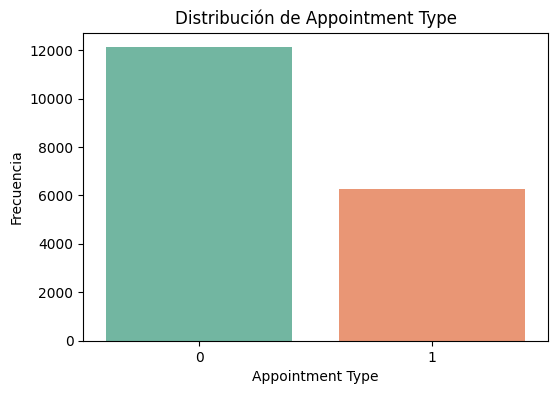

In [63]:
# Variables categóricas según tu descripción
cat_cols = ['Sex', 'Insurance Type', 'Day', 'Month', 'Appointment Type']

print("\n Frecuencia de variables categóricas:")

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df_limpio[col].value_counts().sort_index())

    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df_limpio, palette='Set2', order=sorted(df_limpio[col].unique()))
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

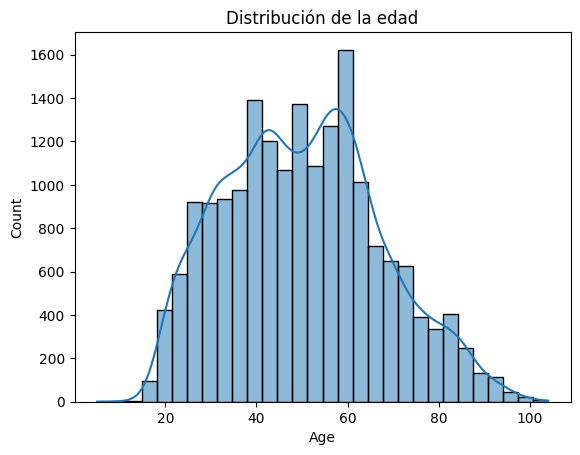

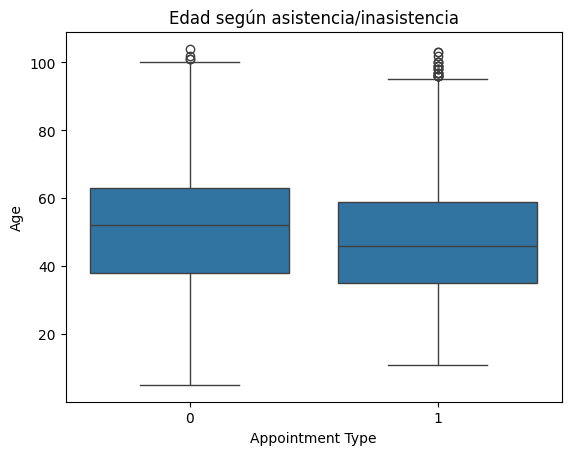

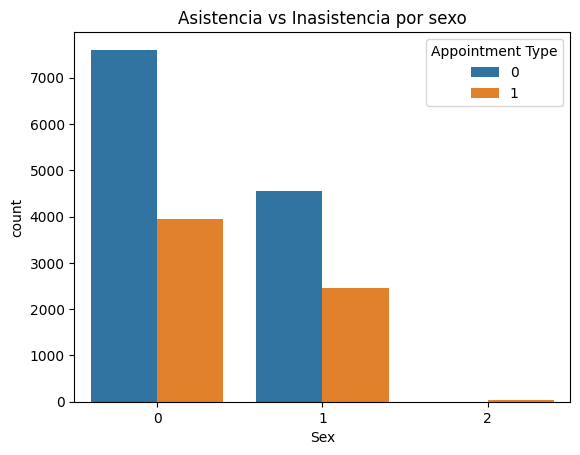

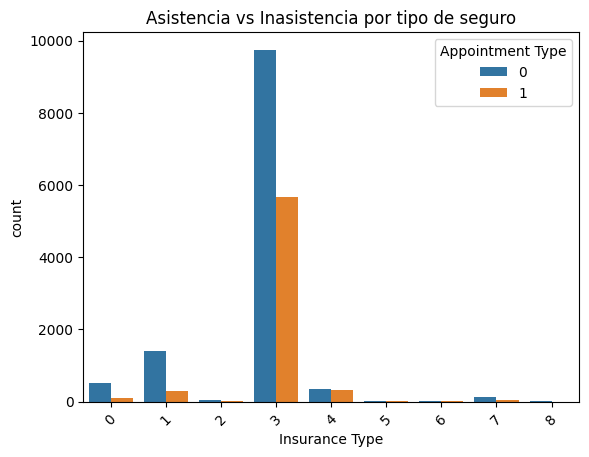

In [64]:

# ===========================
#  Variables sociodemográficas
# ===========================

# Edad
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Distribución de la edad")
plt.show()

sns.boxplot(x='Appointment Type', y='Age', data=df)
plt.title("Edad según asistencia/inasistencia")
plt.show()

# Sexo
sns.countplot(x="Sex", hue="Appointment Type", data=df)
plt.title("Asistencia vs Inasistencia por sexo")
plt.show()

# Tipo de seguro
sns.countplot(x="Insurance Type", hue="Appointment Type", data=df)
plt.title("Asistencia vs Inasistencia por tipo de seguro")
plt.xticks(rotation=45)
plt.show()

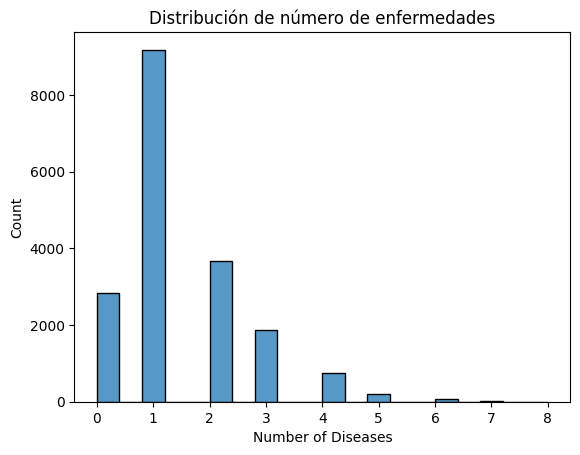

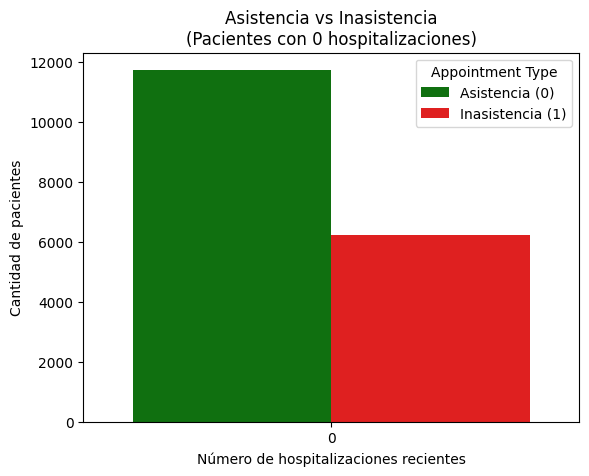

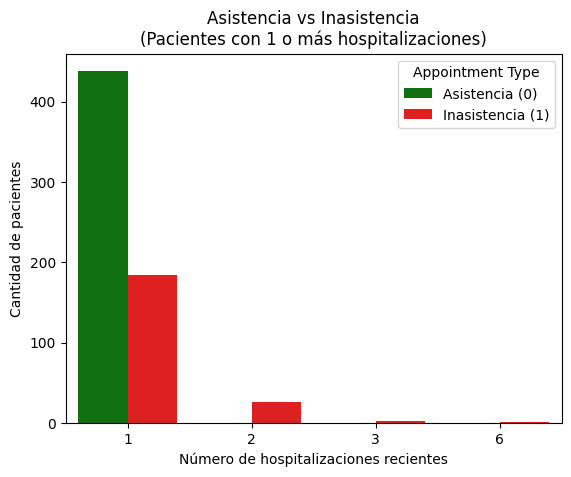

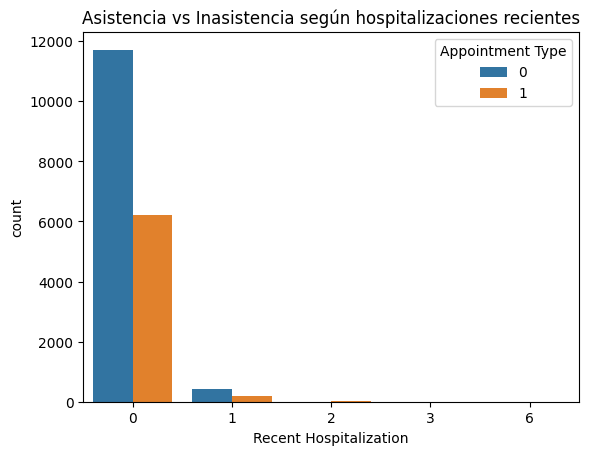

In [65]:
# ===========================
#  Variables clínicas
# ===========================

# Número de enfermedades
sns.histplot(df['Number of Diseases'], bins=20, kde=False)
plt.title("Distribución de número de enfermedades")
plt.show()

# --- Grupo 1: Pacientes con 0 hospitalizaciones recientes ---
subset_no_hosp = df[df['Recent Hospitalization'] == 0]

sns.countplot(x="Recent Hospitalization", hue="Appointment Type", data=subset_no_hosp, palette=["green", "red"])
plt.title("Asistencia vs Inasistencia\n(Pacientes con 0 hospitalizaciones)")
plt.xlabel("Número de hospitalizaciones recientes")
plt.ylabel("Cantidad de pacientes")
plt.legend(title="Appointment Type", labels=["Asistencia (0)", "Inasistencia (1)"])
plt.show()

# --- Grupo 2: Pacientes con 1 o más hospitalizaciones recientes ---
subset_hosp = df[df['Recent Hospitalization'] > 0]

sns.countplot(x="Recent Hospitalization", hue="Appointment Type", data=subset_hosp, palette=["green", "red"])
plt.title("Asistencia vs Inasistencia\n(Pacientes con 1 o más hospitalizaciones)")
plt.xlabel("Número de hospitalizaciones recientes")
plt.ylabel("Cantidad de pacientes")
plt.legend(title="Appointment Type", labels=["Asistencia (0)", "Inasistencia (1)"])
plt.show()


# Hospitalización reciente
sns.countplot(x="Recent Hospitalization", hue="Appointment Type", data=df)
plt.title("Asistencia vs Inasistencia según hospitalizaciones recientes")
plt.show()



C:\Users\alejo\AppData\Local\Temp\ipykernel_23136\786280105.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Appointment Type", data=subset_no_hosp, palette=["green", "red"])


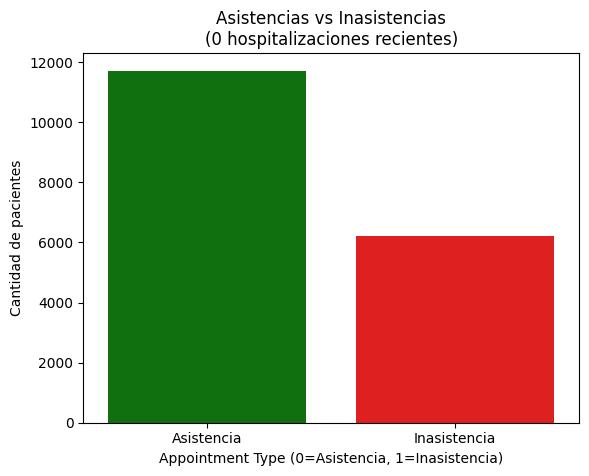

C:\Users\alejo\AppData\Local\Temp\ipykernel_23136\786280105.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Appointment Type", data=subset_hosp, palette=["green", "red"])


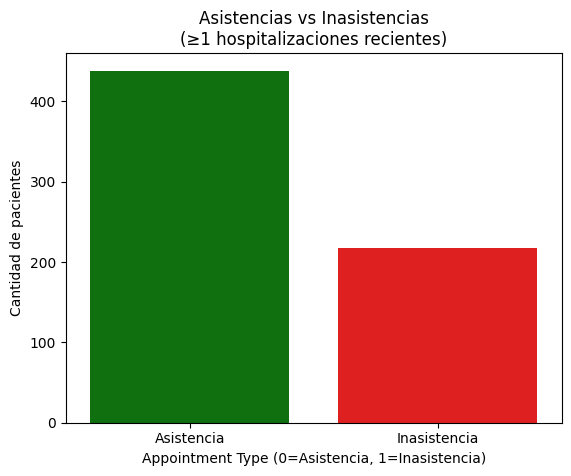

In [66]:
# --- Grupo 1: Pacientes con 0 hospitalizaciones recientes ---
subset_no_hosp = df[df['Recent Hospitalization'] == 0]

sns.countplot(x="Appointment Type", data=subset_no_hosp, palette=["green", "red"])
plt.title("Asistencias vs Inasistencias\n(0 hospitalizaciones recientes)")
plt.xlabel("Appointment Type (0=Asistencia, 1=Inasistencia)")
plt.ylabel("Cantidad de pacientes")
plt.xticks([0,1], ["Asistencia", "Inasistencia"])
plt.show()

# --- Grupo 2: Pacientes con 1 o más hospitalizaciones recientes ---
subset_hosp = df[df['Recent Hospitalization'] > 0]

sns.countplot(x="Appointment Type", data=subset_hosp, palette=["green", "red"])
plt.title("Asistencias vs Inasistencias\n(≥1 hospitalizaciones recientes)")
plt.xlabel("Appointment Type (0=Asistencia, 1=Inasistencia)")
plt.ylabel("Cantidad de pacientes")
plt.xticks([0,1], ["Asistencia", "Inasistencia"])
plt.show()

## Matriz de Correlación


Matriz de correlación:


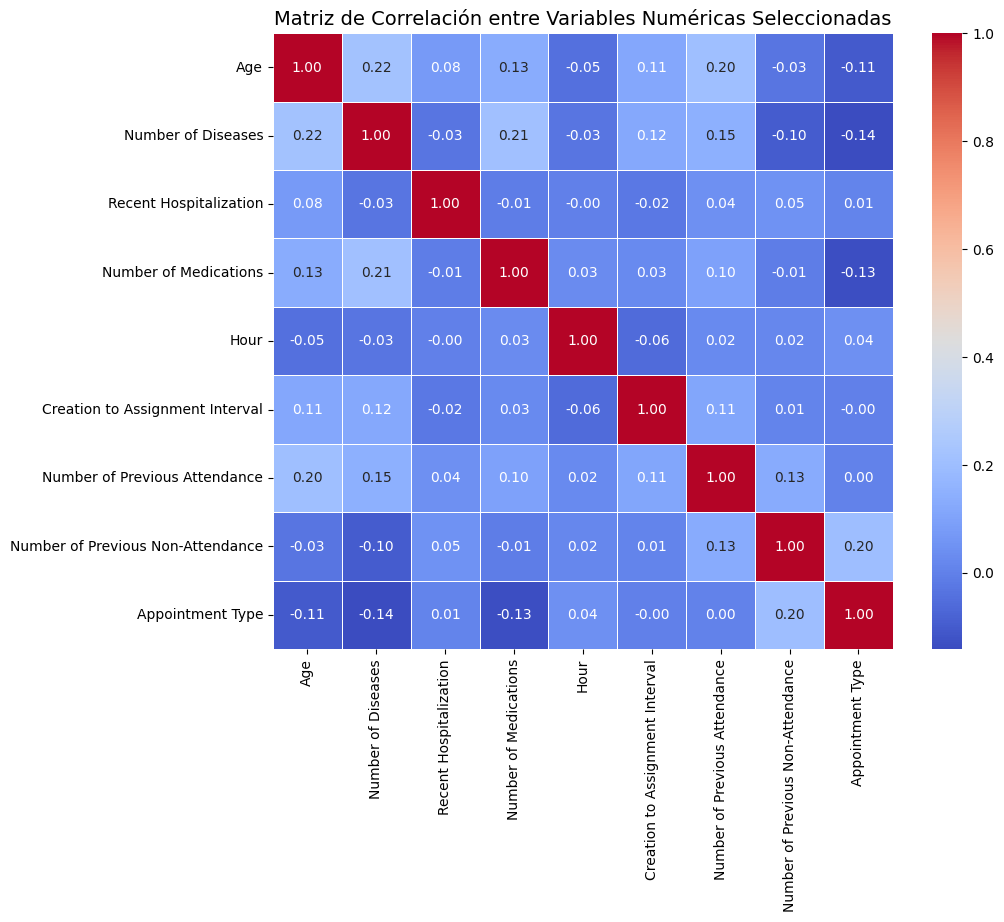


Correlación con la variable objetivo (Appointment Type):
Appointment Type                     1.000000
Number of Previous Non-Attendance    0.197838
Hour                                 0.042700
Recent Hospitalization               0.008235
Number of Previous Attendance        0.001388
Creation to Assignment Interval     -0.000684
Age                                 -0.105301
Number of Medications               -0.134646
Number of Diseases                  -0.141564
Name: Appointment Type, dtype: float64


In [67]:
num_cols = [
    'Age', 'Number of Diseases', 'Recent Hospitalization',
    'Number of Medications', 'Hour',
    'Creation to Assignment Interval',
    'Number of Previous Attendance', 'Number of Previous Non-Attendance'
]

# Incluimos la variable objetivo para medir su correlación con las demás
cols_corr = num_cols + ['Appointment Type']

# Calcular la matriz de correlación solo con las columnas seleccionadas
corr_matrix = df_limpio[cols_corr].corr()

# Mostrar la matriz numérica
print("\nMatriz de correlación:")
# print(corr_matrix)

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Numéricas Seleccionadas", fontsize=14)
plt.show()

# Correlación de cada variable con la variable objetivo
target_corr = corr_matrix["Appointment Type"].sort_values(ascending=False)
print("\nCorrelación con la variable objetivo (Appointment Type):")
print(target_corr)


# Análisis de Outliers

Detección de valores atípicos en variables cuantitativas usando el método IQR (Rango Intercuartílico)

In [68]:
# Primero veamos los nombres de las columnas en el dataset
print("Columnas disponibles en el dataset:")
print(df.columns.tolist())

Columnas disponibles en el dataset:
['Appointment Type', 'Age', 'Sex', 'Insurance Type', 'Number of Diseases', 'Recent Hospitalization', 'Number of Medications', 'Hour', 'Day', 'Month', 'Creation to Assignment Interval', 'Number of Previous Attendance', 'Number of Previous Non-Attendance']


In [69]:
# Definir las variables a analizar basadas en el diccionario de datos
# Los nombres deben coincidir EXACTAMENTE con las columnas del dataset

variables_to_analyze = {
    'Number of Diseases': 'Número de enfermedades',
    'Recent Hospitalization': 'Hospitalizaciones recientes (3 meses)',
    'Number of Medications': 'Número de medicamentos',
    'Hour': 'Hora de la cita',
    'Creation to Assignment Interval': 'Intervalo creación-asignación (días)',
    'Number of Previous Attendance': 'Número de asistencias previas',
    'Number of Previous Non-Attendance': 'Número de inasistencias previas'
}

# Mostrar las variables que se van a analizar
print("Variables a analizar para detección de outliers:")
for key, value in variables_to_analyze.items():
    print(f"  - {key}: {value}")

Variables a analizar para detección de outliers:
  - Number of Diseases: Número de enfermedades
  - Recent Hospitalization: Hospitalizaciones recientes (3 meses)
  - Number of Medications: Número de medicamentos
  - Hour: Hora de la cita
  - Creation to Assignment Interval: Intervalo creación-asignación (días)
  - Number of Previous Attendance: Número de asistencias previas
  - Number of Previous Non-Attendance: Número de inasistencias previas


## Método de detección: IQR (Interquartile Range)

El método IQR identifica outliers como aquellos valores que están:
- **Por debajo** de Q1 - 1.5 × IQR
- **Por encima** de Q3 + 1.5 × IQR

Donde:
- Q1 = Primer cuartil (25%)
- Q3 = Tercer cuartil (75%)
- IQR = Q3 - Q1

In [70]:
def detect_outliers_iqr(data, column):
    """
    Detecta outliers usando el método IQR (Rango Intercuartílico)
    
    Parámetros:
    - data: DataFrame
    - column: nombre de la columna a analizar
    
    Retorna:
    - Diccionario con estadísticas de outliers
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Límites para outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identificar outliers
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    # Calcular estadísticas
    total_values = len(data[column].dropna())
    n_outliers = len(outliers)
    percentage = (n_outliers / total_values * 100) if total_values > 0 else 0
    
    return {
        'Variable': column,
        'Total de registros': total_values,
        'Cantidad de outliers': n_outliers,
        'Porcentaje (%)': round(percentage, 2),
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Límite inferior': round(lower_bound, 2),
        'Límite superior': round(upper_bound, 2),
        'Min outlier': round(outliers[column].min(), 2) if n_outliers > 0 else None,
        'Max outlier': round(outliers[column].max(), 2) if n_outliers > 0 else None
    }

print("✓ Función de detección de outliers definida")

✓ Función de detección de outliers definida


## Tabla de Resumen de Outliers

In [71]:
# Analizar outliers para cada variable
outlier_results = []

for var_name in variables_to_analyze.keys():
    if var_name in df.columns:
        result = detect_outliers_iqr(df, var_name)
        outlier_results.append(result)
    else:
        print(f"⚠ Advertencia: La variable '{var_name}' no se encuentra en el dataset")

# Crear DataFrame con los resultados
df_outliers = pd.DataFrame(outlier_results)

print("=" * 100)
print("RESUMEN DE OUTLIERS - VARIABLES CUANTITATIVAS")
print("=" * 100)
print(df_outliers[['Variable', 'Total de registros', 'Cantidad de outliers', 'Porcentaje (%)']].to_string(index=False))
print("=" * 100)

RESUMEN DE OUTLIERS - VARIABLES CUANTITATIVAS
                         Variable  Total de registros  Cantidad de outliers  Porcentaje (%)
               Number of Diseases               18587                  1047            5.63
           Recent Hospitalization               18587                   655            3.52
            Number of Medications               18587                  4631           24.92
                             Hour               18587                     0            0.00
  Creation to Assignment Interval               18587                   874            4.70
    Number of Previous Attendance               18587                   393            2.11
Number of Previous Non-Attendance               18587                   966            5.20


In [72]:
# Mostrar tabla completa con todos los detalles
print("\n" + "=" * 120)
print("TABLA DETALLADA DE OUTLIERS")
print("=" * 120)
print(df_outliers.to_string(index=False))
print("=" * 120)


TABLA DETALLADA DE OUTLIERS
                         Variable  Total de registros  Cantidad de outliers  Porcentaje (%)  Q1   Q3  IQR  Límite inferior  Límite superior  Min outlier  Max outlier
               Number of Diseases               18587                  1047            5.63 1.0  2.0  1.0             -0.5              3.5          4.0          8.0
           Recent Hospitalization               18587                   655            3.52 0.0  0.0  0.0              0.0              0.0          1.0          6.0
            Number of Medications               18587                  4631           24.92 0.0  0.0  0.0              0.0              0.0          1.0         18.0
                             Hour               18587                     0            0.00 9.0 14.0  5.0              1.5             21.5          NaN          NaN
  Creation to Assignment Interval               18587                   874            4.70 8.0 35.0 27.0            -32.5             75.5  

### Análisis detallado: `Insurance Type`
En esta sección se realiza un análisis específico de la variable `Insurance Type` (nominal). Se incluyen: distribución por categoría, proporción de no-shows por categoría, una tabla resumen con conteos y porcentajes, una prueba estadística de asociación (chi-cuadrado) entre `Insurance Type` y `Appointment Type` y visualizaciones (barras y gráfico apilado).


Resumen por Insurance Type:
      Insurance_Label  Count  Percent  NoShow_Rate_pct
              Prepaid  15241    82.88            36.20
         Contributory   1670     9.08            17.37
              Private    658     3.58            47.72
                  ARL    601     3.27            16.64
  Other Institutional    153     0.83            22.88
           Subsidized     42     0.23            26.19
International Private     12     0.07            33.33
                Other      7     0.04            57.14
    Unknown/Undefined      6     0.03            16.67


C:\Users\alejo\AppData\Local\Temp\ipykernel_23136\3022443889.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=summary, x='Insurance_Label', y='Count', palette='Set2')


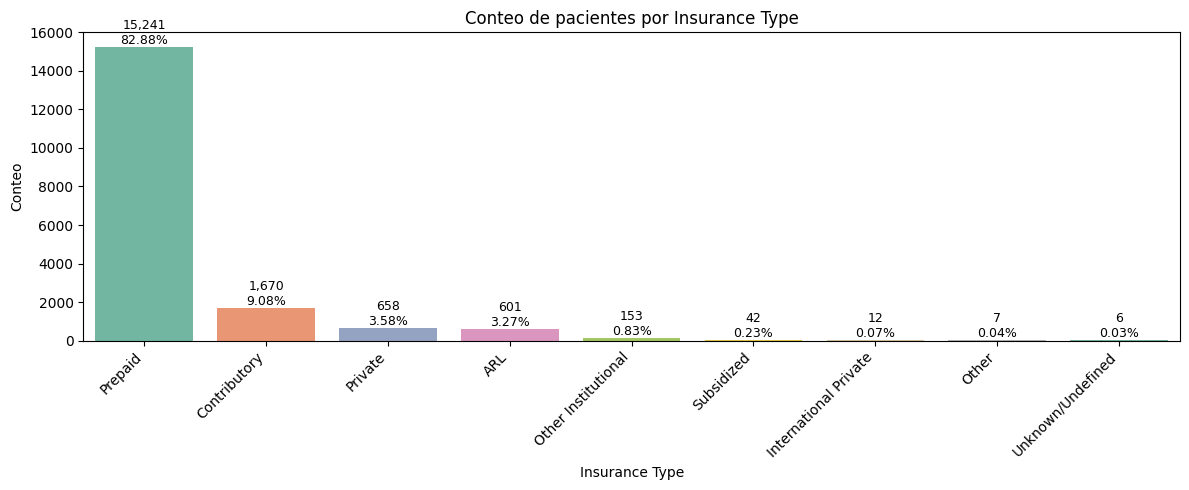

C:\Users\alejo\AppData\Local\Temp\ipykernel_23136\3022443889.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=summary, x='Insurance_Label', y='NoShow_Rate_pct', palette='rocket')


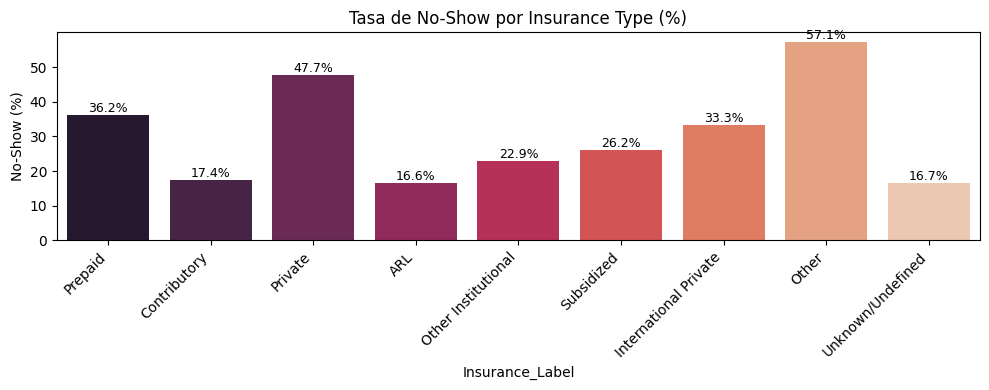


Tabla de contingencia (Insurance x Appointment Type):
Appointment Type          0     1
Insurance_Label                  
ARL                     501   100
Contributory           1380   290
International Private     8     4
Other                     3     4
Other Institutional     118    35
Prepaid                9724  5517
Private                 344   314
Subsidized               31    11
Unknown/Undefined         5     1

Prueba chi-cuadrado: chi2=385.907, p-valor=0.0000, dof=8


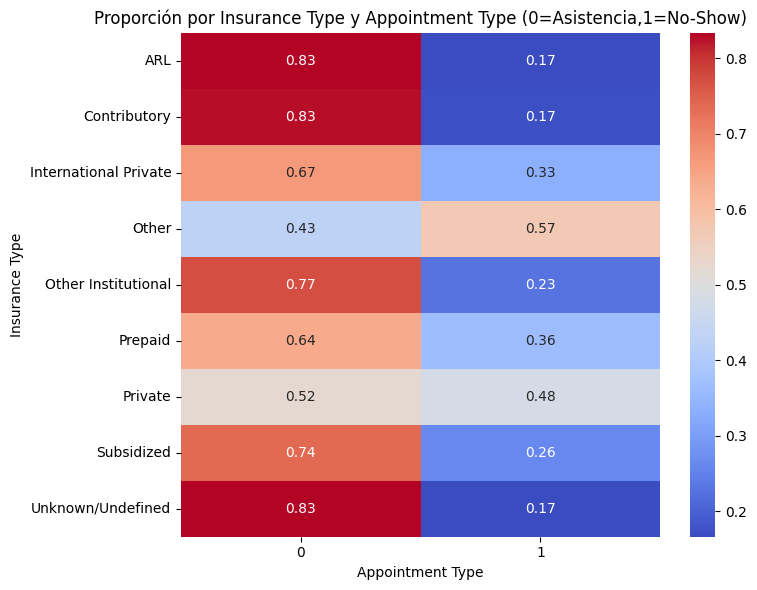

,Insurance_Label,Count,Percent,NoShow_Rate_pct
0,Prepaid,15241,82.88,36.20
1,Contributory,1670,9.08,17.37
2,Private,658,3.58,47.72
3,ARL,601,3.27,16.64
4,Other Institutional,153,0.83,22.88
5,Subsidized,42,0.23,26.19
6,International Private,12,0.07,33.33
7,Other,7,0.04,57.14
8,Unknown/Undefined,6,0.03,16.67


In [73]:
# Análisis cuantitativo y estadístico de 'Insurance Type'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mapeo de códigos a etiquetas (ajusta si el diccionario oficial difiere)
insurance_map = {
    0: 'ARL',
    1: 'Contributory',
    2: 'Subsidized',
    3: 'Prepaid',
    4: 'Private',
    5: 'International Private',
    6: 'Other',
    7: 'Other Institutional',
    8: 'Unknown/Undefined'
}

col = 'Insurance Type'

# Verificaciones básicas
if 'df_limpio' not in globals():
    try:
        df_limpio
    except Exception:
        raise NameError("La variable 'df_limpio' no está definida. Ejecuta la celda de limpieza antes de este análisis.")

if col not in df_limpio.columns:
    raise KeyError(f"Columna '{col}' no encontrada en df_limpio. Columnas disponibles: {df_limpio.columns.tolist()}")

# Crear copia con etiquetas legibles
df_ins = df_limpio.copy()
# Asegurar que los códigos sean enteros cuando sea posible
try:
    df_ins[col] = pd.to_numeric(df_ins[col], errors='coerce').astype('Int64')
except Exception:
    pass

# Mapear etiquetas; mantener valores inesperados como 'Other/Unknown'
df_ins['Insurance_Label'] = df_ins[col].map(insurance_map).fillna('Other/Unknown')

# Resumen: conteos y porcentajes
summary = df_ins['Insurance_Label'].value_counts(dropna=False).rename_axis('Insurance_Label').reset_index(name='Count')
summary['Percent'] = (summary['Count'] / summary['Count'].sum() * 100).round(2)

# Tasa de no-show (Appointment Type: 1 = no-show)
if 'Appointment Type' not in df_ins.columns:
    raise KeyError("La columna 'Appointment Type' no existe en el dataset. Asegúrate de que el target esté presente.")

no_show_rate = df_ins.groupby('Insurance_Label')['Appointment Type'].mean().reset_index(name='NoShow_Rate')
no_show_rate['NoShow_Rate_pct'] = (no_show_rate['NoShow_Rate'] * 100).round(2)

# Combinar resumen
summary = summary.merge(no_show_rate[['Insurance_Label','NoShow_Rate_pct']], on='Insurance_Label', how='left')
summary = summary.sort_values(by='Count', ascending=False)

print('\nResumen por Insurance Type:')
print(summary.to_string(index=False))

# Guardar resumen opcional (descomentar si se desea)
# summary.to_csv('../data/outputs/insurance_type_summary.csv', index=False)

# Gráfica 1: barras (conteo) y anotación de porcentaje
plt.figure(figsize=(12,5))
ax = sns.barplot(data=summary, x='Insurance_Label', y='Count', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Conteo de pacientes por Insurance Type')
plt.xlabel('Insurance Type')
plt.ylabel('Conteo')
for p, pct in zip(ax.patches, summary['Percent']):
    ax.annotate(f"{int(p.get_height()):,}\n{pct}%", (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Gráfica 2: tasa de no-show por insurance
plt.figure(figsize=(10,4))
ax2 = sns.barplot(data=summary, x='Insurance_Label', y='NoShow_Rate_pct', palette='rocket')
plt.xticks(rotation=45, ha='right')
plt.title('Tasa de No-Show por Insurance Type (%)')
plt.ylabel('No-Show (%)')
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.1f}%", (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Tabla de contingencia y prueba chi-cuadrado
from scipy.stats import chi2_contingency

cont_table = pd.crosstab(df_ins['Insurance_Label'], df_ins['Appointment Type'])
print('\nTabla de contingencia (Insurance x Appointment Type):')
print(cont_table)

chi2, p, dof, expected = chi2_contingency(cont_table)
print(f"\nPrueba chi-cuadrado: chi2={chi2:.3f}, p-valor={p:.4f}, dof={dof}")

# Mostrar heatmap de la proporción de no-shows por insurance (normalizado por fila)
prop_table = cont_table.div(cont_table.sum(axis=1), axis=0)
plt.figure(figsize=(8,6))
# Seleccionar columnas 0 y 1 si existen como enteros; si no, tomar todas las columnas
heat_cols = []
if 0 in prop_table.columns and 1 in prop_table.columns:
    heat_cols = [0, 1]
else:
    # fallback: usar string column names si existen
    heat_cols = [c for c in prop_table.columns]

sns.heatmap(prop_table[heat_cols].fillna(0), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Proporción por Insurance Type y Appointment Type (0=Asistencia,1=No-Show)')
plt.xlabel('Appointment Type')
plt.ylabel('Insurance Type')
plt.tight_layout()
plt.show()

# Resultado final para revisión
summary
